# Aula 01: uma primeira tabela

Este notebook acompanha a primeira aula de Introdução à Ciência de Dados. A ideia é mostrar que uma análise começa com uma pergunta, não com um algoritmo.

## Pergunta

Como poderiamos investigar se o acesso a equipamentos publicos varia entre regioes de uma cidade?

Esta ainda não é uma pergunta perfeita. Ela precisa virar uma comparação mensurável.

## Dados didáticos

A tabela abaixo é pequena e fictícia. Ela serve para discutir conceitos iniciais: linha, coluna, unidade observacional, variável e indicador.

In [1]:
import pandas as pd

dados = pd.DataFrame({
    "regiao": ["Centro-Sul", "Venda Nova", "Barreiro", "Pampulha", "Norte"],
    "populacao": [283776, 262183, 282552, 226110, 212055],
    "equipamentos_publicos": [138, 74, 81, 95, 62],
    "area_km2": [31.7, 28.3, 53.5, 51.0, 32.6]
})

dados

,regiao,populacao,equipamentos_publicos,area_km2
0,Centro-Sul,283776,138,31.7
1,Venda Nova,262183,74,28.3
2,Barreiro,282552,81,53.5
3,Pampulha,226110,95,51.0
4,Norte,212055,62,32.6


::: {.callout-note title="Interpretação"}
A pequena tabela foi construída para tornar visível a passagem entre observações, variáveis e perguntas. Os números ainda não sustentam generalizações: servem para exercitar a leitura da estrutura dos dados.
:::

## Unidade observacional e variáveis

- Cada linha representa uma região.
- `população`, `equipamentos_publicos` e `area_km2` são variáveis.
- A tabela ainda não responde tudo, mas já permite criar indicadores.

In [2]:
dados["equipamentos_por_10k"] = (
    dados["equipamentos_publicos"] / dados["populacao"] * 10_000
)

dados["equipamentos_por_km2"] = (
    dados["equipamentos_publicos"] / dados["area_km2"]
)

dados.round(2)

,regiao,populacao,equipamentos_publicos,area_km2,equipamentos_por_10k,equipamentos_por_km2
0,Centro-Sul,283776,138,31.7,4.86,4.35
1,Venda Nova,262183,74,28.3,2.82,2.61
2,Barreiro,282552,81,53.5,2.87,1.51
3,Pampulha,226110,95,51.0,4.20,1.86
4,Norte,212055,62,32.6,2.92,1.90


## Comparando regioes

Ordenar uma tabela é uma forma simples de começar a explorar dados. A escolha do indicador muda a história que vemos.

In [3]:
dados.sort_values("equipamentos_por_10k", ascending=False)[
    ["regiao", "equipamentos_por_10k", "equipamentos_por_km2"]
].round(2)

,regiao,equipamentos_por_10k,equipamentos_por_km2
0,Centro-Sul,4.86,4.35
3,Pampulha,4.20,1.86
4,Norte,2.92,1.90
2,Barreiro,2.87,1.51
1,Venda Nova,2.82,2.61


## Visualizacao rapida

Um gráfico simples pode ajudar a enxergar diferenças, mas ele não substitui a pergunta nem resolve as limitações dos dados.

Text(0, 0.5, '')

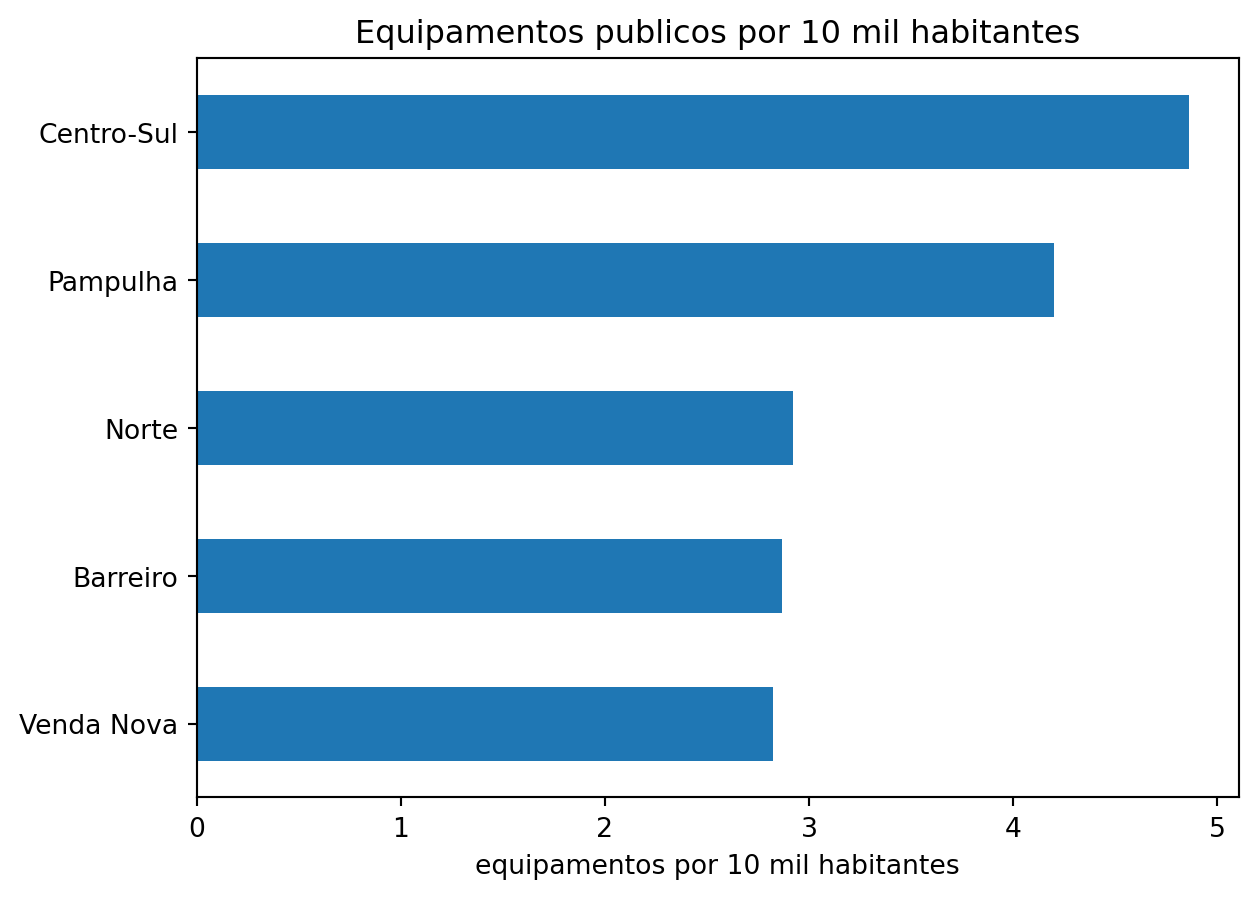

In [4]:
ax = dados.sort_values("equipamentos_por_10k").plot.barh(
    x="regiao",
    y="equipamentos_por_10k",
    legend=False,
    title="Equipamentos publicos por 10 mil habitantes"
)
ax.set_xlabel("equipamentos por 10 mil habitantes")
ax.set_ylabel("")

::: {.callout-note title="Interpretação"}
O gráfico permite comparar categorias mais rapidamente que a tabela, mas não cria informação nova. A conclusão continua limitada ao conjunto didático observado.
:::

## Limitacoes

Esta análise não mede qualidade dos equipamentos, distância real, demanda, horário de funcionamento ou desigualdades dentro de cada região.

Uma boa conclusão precisa dizer o que foi medido e o que ficou fora da tabela.

## Para praticar

1. Crie outro indicador usando as colunas disponiveis.
2. Explique em duas frases o que esse indicador mede.
3. Escreva uma pergunta que esta tabela não consegue responder.

# Guia teórico da Aula 01

## O que é ciência de dados?

Ciência de dados combina formulação de perguntas, coleta, organização, computação, estatística, conhecimento do domínio e comunicação. O resultado não é apenas uma previsão: é uma afirmação cuja origem, incerteza e consequência podem ser examinadas.

A área foi impulsionada pela combinação de três forças: grande coleta de dados pela internet e por sensores, aumento do poder computacional — incluindo GPUs — e desenvolvimento de técnicas e algoritmos. Nenhuma dessas forças elimina a necessidade de perguntas bem formuladas e dados adequados.

## O ciclo de uma análise

1. formular uma pergunta verificável;
2. compreender como os dados foram produzidos;
3. obter e organizar a base;
4. explorar e visualizar;
5. modelar ou inferir;
6. avaliar incerteza e limitações;
7. comunicar e decidir;
8. monitorar consequências e revisar.

O ciclo não é linear: resultados inesperados frequentemente nos fazem voltar à pergunta ou à coleta.

## Correlação, causalidade e responsabilidade

Correlação descreve variação conjunta, mas não identifica automaticamente causa. Confusão, seleção, coincidência e causalidade reversa podem produzir associações. Esse cuidado prepara a Aula 02.

Responsabilidade acompanha todo o ciclo. LGPD, finalidade, minimização, segurança, transparência e não discriminação não são etapas finais. Um sistema pode ter boa acurácia média e ainda prejudicar grupos específicos. Sempre pergunte quem forneceu os dados, quem está ausente, quem recebe benefícios e quem assume os riscos.
